# Single-parameter scans (JAX)

Resamples flux per trajectory via the JAX latent flow-matching sampler,
 then sweeps `rlt / rln / shat / q` against the gyaradax-precomputed scan
 geometries. Produces the violin and marginal-histogram panels used in the paper.


In [1]:
%load_ext autoreload
%autoreload 2

import os, sys, pickle
sys.path.insert(0, "..")
sys.path.insert(0, "../..")  # outer torch repo, needed to unpickle stats/latents that reference neugk.*
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0")

import numpy as np
import yaml
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from mpl_toolkits.axes_grid1 import make_axes_locatable

import jax, jax.numpy as jnp, jax.random as jr
import gyaradax  # ensures jax_enable_x64=True before AE/DiT jit

from plot_help import (
    apply_paper_style, save_fig,
    COLOR_GYROFLOW, COLOR_GKW, COLOR_REF,
)
apply_paper_style()

ID_TRAJS  = ["iteration_8", "iteration_115", "iteration_131",
             "iteration_148", "iteration_232", "iteration_262"]
OOD_TRAJS = [f"ood_iteration_{i}" for i in range(5)]
RESULTS_DIR = "./figs/paper"

In [2]:
from neugk_jax.translate import build_ae_from_config, build_dit_from_config, load_or_translate

AE_CKPT    = "/restricteddata/ukaea/checkpoints/neurips26/AE_noCond/20260405_022851_327"
DIT_CKPT   = "/restricteddata/ukaea/checkpoints/neurips26/DIFF_FLOW/20260412_180101_948"
LATENTS_PKL = "/local00/bioinf/galletti/preprocessed_kvikio/diff_train_latents_offset80_mu_57f5caf20c1e_latents_ae327.pkl"
STATS_PKL   = "/local00/bioinf/galletti/preprocessed_kvikio/df_flux_phi_offset80_mu_57f5caf2_stats.pkl"
DATA_DIR    = "/local00/bioinf/galletti/preprocessed_kvikio"

ae = load_or_translate(build_ae_from_config(f"{AE_CKPT}/config.yaml", key=jr.PRNGKey(0)),
                       f"{AE_CKPT}/best.pth")
dit = load_or_translate(build_dit_from_config(f"{DIT_CKPT}/config.yaml", ae, key=jr.PRNGKey(0)),
                        f"{DIT_CKPT}/best.pth")

with open(LATENTS_PKL, "rb") as f:
    _lat = pickle.load(f)
_xs = np.stack([v["x"] for v in _lat.values()], axis=0)
latent_scale = float(1.0 / np.std(_xs))
print(f"ae bottleneck: grid={ae.bottleneck_grid_size}, dim={ae.bottleneck_dim}")
print(f"dit latent_shape: {dit.latent_shape}")
print(f"latent_scale: {latent_scale:.6f}")

cuBLAS < 13.2 (120804 found) has a known issue where many kernels free TMEM buffers multiple times. Executing a cuBLAS kernel concurrently with another kernel (e.g. on another stream) can lead to silent data corruption.


/system/apps/userenv/galletti/mhd/bin/../lib/gcc/x86_64-conda-linux-gnu/11.2.0/../../../../x86_64-conda-linux-gnu/bin/ld: cannot find -laio: No such file or directory
collect2: error: ld returned 1 exit status
/system/apps/userenv/galletti/mhd/bin/../lib/gcc/x86_64-conda-linux-gnu/11.2.0/../../../../x86_64-conda-linux-gnu/bin/ld: cannot find -lcufile: No such file or directory
collect2: error: ld returned 1 exit status
/system/apps/userenv/galletti/mhd/lib/python3.12/site-packages/transformers/utils/hub.py:128: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


  translated torch -> jax: 0 missing, 0 unused
  translated torch -> jax: 0 missing, 0 unused
ae bottleneck: grid=(4, 2, 9, 4), dim=256
dit latent_shape: (4, 2, 9, 4, 256)
latent_scale: 0.047905


In [3]:
from neugk_jax.dataset import CycloneDataset, NumpyBackend
from neugk_jax.diffusion.flow_matching import euler_sample
from neugk_jax.evaluate.integrals import gyaradax_flux_integrals

N_FLUX_SAMPLES = 64
N_EULER        = 15
GEN_BATCH      = 16
COND_KEYS      = sorted(["itg", "dg", "s_hat", "q"])  # matches torch DiT slot order

_ds = CycloneDataset(
    path=DATA_DIR, split="train",
    trajectories=ID_TRAJS,
    fields_to_load=("df",),
    conditions=tuple(COND_KEYS),
    mode="ae", backend=NumpyBackend(),
    separate_zf=True, offset=80,
    normalization={"df": {"type": "zscore", "agg_axes": [0, 1, 3, 4, 5]}},
    normalization_scope="dataset",
    normalization_stats=STATS_PKL,
)


def _sample_decode(key, cond, n_steps):
    shape = (cond.shape[0], *ae.bottleneck_grid_size, int(ae.bottleneck_dim))
    latent = euler_sample(
        lambda x, t, c: dit(x, t, c),
        key=key, shape=shape, cond=cond,
        steps=n_steps, latent_scale=latent_scale,
    )
    return jax.vmap(ae.decode)(latent)["df"]


def _denormalize_batch(df_batch, fid):
    return np.stack([
        np.asarray(_ds.denormalize(fid, df=np.asarray(df_batch[b])))
        for b in range(df_batch.shape[0])
    ])


_sample_decode_jit = jax.jit(_sample_decode, static_argnums=2)

In [4]:
def _flux_for_traj(traj):
    fid = next((i for i, fp in enumerate(_ds.files) if traj in fp), None)
    if fid is None:
        return np.array([], dtype=float)
    meta = _ds.metadata[fid]
    cond_vec = jnp.asarray([float(np.squeeze(meta[{"itg":"ion_temp_grad","dg":"density_grad"}.get(k, k)]))
                            for k in COND_KEYS], dtype=jnp.float32)
    geom = {k: jnp.asarray(np.ascontiguousarray(v)) for k, v in meta["geometry"].items()}
    krho = np.asarray(geom["krho"])
    geom["parseval"] = jnp.where(jnp.abs(krho) < 1e-12, 1.0, 2.0).astype(jnp.float64)

    fluxes, n_done = [], 0
    key = jr.PRNGKey(hash(traj) & 0xFFFFFFFF)
    while n_done < N_FLUX_SAMPLES:
        b = min(GEN_BATCH, N_FLUX_SAMPLES - n_done)
        key, sk = jr.split(key)
        cond_b = jnp.broadcast_to(cond_vec, (b, cond_vec.shape[0]))
        df_norm = _sample_decode_jit(sk, cond_b, N_EULER)
        df_denorm = _denormalize_batch(df_norm, fid)
        _, eflux = gyaradax_flux_integrals(jnp.asarray(df_denorm), geom)
        fluxes.extend(np.asarray(eflux).reshape(b, -1).sum(axis=-1).tolist())
        n_done += b
    return np.asarray(fluxes, dtype=float)


samples_flux, samples_gtmean = {}, {}
for t in ID_TRAJS:
    sf = _flux_for_traj(t)
    fid = next(i for i, fp in enumerate(_ds.files) if t in fp)
    gt = float(np.mean(_ds.metadata[fid]["flux"][-80:]))
    samples_flux[t] = sf
    samples_gtmean[t] = gt
    finite = sf[np.isfinite(sf)]
    print(f"  {t:>22s}  N={finite.size:3d}  mean(Q^)={finite.mean() if finite.size else float('nan'):8.2f}  GT={gt:8.2f}")

E0521 16:49:06.817291 1818758 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


             iteration_8  N= 64  mean(Q^)=  138.45  GT=  146.25
           iteration_115  N= 64  mean(Q^)=   65.01  GT=   74.92
           iteration_131  N= 64  mean(Q^)=  121.42  GT=  142.04
           iteration_148  N= 64  mean(Q^)=   75.09  GT=   70.38
           iteration_232  N= 64  mean(Q^)=   66.46  GT=   71.74
           iteration_262  N= 64  mean(Q^)=  151.85  GT=  145.95


In [5]:
SCAN_OUT_ROOT   = "/system/user/publicwork/galletti/neurips_scan"
SCAN_RETRY_ROOT = "/system/user/publicwork/galletti/neurips_scan_retry"
SCAN_CFG_ROOT   = "/system/user/galletti/git/gyaradax/configs/scan"
PARAMS         = ["rlt", "rln", "shat", "q"]
N_SCAN_SAMPLES = 64
GT_TAIL_BLOCKS = 80
_YAML_PATH = {
    "rlt":  ("physics",  "rlt"),
    "rln":  ("physics",  "rln"),
    "shat": ("geometry", "shat"),
    "q":    ("geometry", "q"),
}


def _load_scan_geometry(param, it_name):
    with open(os.path.join(SCAN_OUT_ROOT, param, it_name, "geometry.pkl"), "rb") as f:
        gd = pickle.load(f)
    krho = np.asarray(gd["krho"])
    out = {k: jnp.asarray(np.ascontiguousarray(np.asarray(v))) for k, v in gd.items()
           if hasattr(v, "__array__") or isinstance(v, (list, tuple, int, float))}
    out["parseval"] = jnp.where(jnp.abs(krho) < 1e-12, 1.0, 2.0).astype(jnp.float64)
    for k, v in (("adiabatic", 1.0), ("beta", 0.0), ("nlapar", 0.0), ("nlbpar", 0.0)):
        out.setdefault(k, jnp.float32(v))
    return out


def _parse_scan_iter(param, it_name):
    cfg_path = os.path.join(SCAN_CFG_ROOT, param, f"{it_name}.yaml")
    flux_path = os.path.join(SCAN_OUT_ROOT, param, it_name, "fluxes.npz")
    if not os.path.isfile(cfg_path):
        return None
    cfg = yaml.safe_load(open(cfg_path))
    vals = {k: float(cfg[s][f]) for k, (s, f) in _YAML_PATH.items()}
    cond_map = {"itg": vals["rlt"], "dg": vals["rln"], "q": vals["q"], "s_hat": vals["shat"]}
    cond_vec = np.array([cond_map[k] for k in COND_KEYS], dtype=np.float32)
    SAT_BLOCKS, MIN_BLOCKS = 80, 80 + GT_TAIL_BLOCKS
    gt = float("nan"); gt_src = None
    cands = [flux_path]
    retry_dir = os.path.join(SCAN_RETRY_ROOT, param)
    if os.path.isdir(retry_dir):
        for sub in sorted(os.listdir(retry_dir)):
            if sub.startswith(f"{it_name}_j"):
                cands.append(os.path.join(retry_dir, sub, "fluxes.npz"))
    for c in cands:
        if not os.path.isfile(c):
            continue
        try:
            with np.load(c) as d:
                fl = d["fluxes"]
                if np.isnan(fl).any() or fl.shape[0] < MIN_BLOCKS:
                    continue
                col = fl[:, 1] if fl.ndim == 2 else fl[:, 0, 1]
                gt = float(np.nanmean(col[-GT_TAIL_BLOCKS:]))
                gt_src = c; break
        except Exception:
            continue
    if gt_src is not None and gt_src != flux_path:
        print(f"  [retry-gt] {param}/{it_name}  using {os.path.relpath(gt_src, SCAN_RETRY_ROOT)}")
    return cond_vec, gt, vals


def _flux_for_cond(cond_vec_np, param, it_name):
    geom = _load_scan_geometry(param, it_name)
    cond_vec = jnp.asarray(cond_vec_np)
    fluxes, n_done = [], 0
    key = jr.PRNGKey(hash(f"{param}-{it_name}") & 0xFFFFFFFF)
    while n_done < N_SCAN_SAMPLES:
        b = min(GEN_BATCH, N_SCAN_SAMPLES - n_done)
        key, sk = jr.split(key)
        cond_b = jnp.broadcast_to(cond_vec, (b, cond_vec.shape[0]))
        df_norm = _sample_decode_jit(sk, cond_b, N_EULER)
        df_denorm = _denormalize_batch(df_norm, 0)  # normalization_scope='dataset' -> fid is irrelevant
        _, eflux = gyaradax_flux_integrals(jnp.asarray(df_denorm), geom)
        fluxes.extend(np.asarray(eflux).reshape(b, -1).sum(axis=-1).tolist())
        n_done += b
    return np.asarray(fluxes, dtype=float)


scan_data = {}
for param in PARAMS:
    pdir = os.path.join(SCAN_CFG_ROOT, param)
    if not os.path.isdir(pdir):
        print(f"  skip {param}: no configs at {pdir}"); continue
    it_names = sorted(os.path.splitext(f)[0] for f in os.listdir(pdir)
                      if f.startswith("iteration_") and f.endswith(".yaml"))
    rows = []
    for it_name in it_names:
        parsed = _parse_scan_iter(param, it_name)
        if parsed is None:
            continue
        cond_vec, gt, vals = parsed
        s = _flux_for_cond(cond_vec, param, it_name)
        rows.append({"x": vals[param], "samples": s, "gt": gt, "name": it_name, "vals": vals})
        gt_s = f"{gt:8.2f}" if np.isfinite(gt) else "     nan"
        print(f"  {param:>4s}/{it_name:18s} {param}={vals[param]:7.3f}  GT={gt_s}  pred_mean={float(np.nanmean(s)):8.2f}")
    scan_data[param] = rows
print({k: len(v) for k, v in scan_data.items()})

   rlt/iteration_00       rlt=  1.060  GT=    0.00  pred_mean=    0.20
   rlt/iteration_01       rlt=  3.244  GT=    0.00  pred_mean=    0.83
   rlt/iteration_02       rlt=  5.428  GT=    3.12  pred_mean=    2.30
   rlt/iteration_03       rlt=  7.612  GT=   18.38  pred_mean=   13.07
   rlt/iteration_04       rlt=  9.796  GT=   43.98  pred_mean=   39.28
   rlt/iteration_05       rlt= 11.980  GT=   85.81  pred_mean=   64.69
   rln/iteration_00       rln=  0.004  GT=   45.69  pred_mean=   41.44
   rln/iteration_01       rln=  1.401  GT=   51.71  pred_mean=   42.44
  [retry-gt] rln/iteration_02  using rln/iteration_02_j00/fluxes.npz
   rln/iteration_02       rln=  2.798  GT=   50.52  pred_mean=   42.38
   rln/iteration_03       rln=  4.196  GT=   41.88  pred_mean=   39.44
   rln/iteration_04       rln=  5.593  GT=   29.55  pred_mean=   24.80
   rln/iteration_05       rln=  6.990  GT=   18.56  pred_mean=   10.15
  shat/iteration_00       shat=  0.510  GT=  101.33  pred_mean=  100.09
  shat/

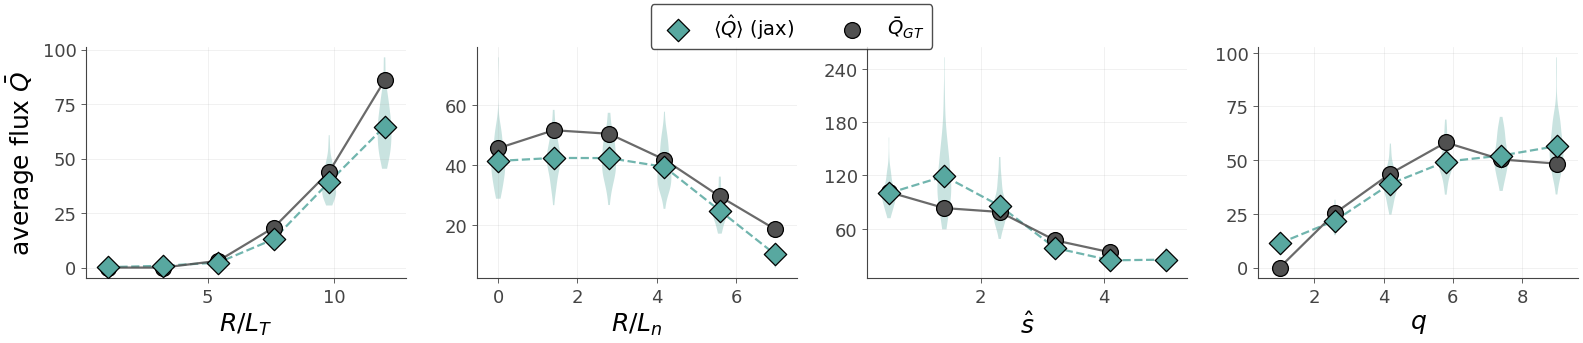

In [6]:
PANEL_LABEL = {"rlt": r"$R/L_T$", "rln": r"$R/L_n$", "shat": r"$\hat{s}$", "q": r"$q$"}
COLOR_SCAN, COLOR_GT = COLOR_GYROFLOW, COLOR_GKW

fig, axes = plt.subplots(1, 4, figsize=(16.0, 3.5), squeeze=False)
for col_i, param in enumerate(PARAMS):
    ax = axes[0, col_i]
    rows = sorted(scan_data.get(param, []), key=lambda r: r["x"])
    if not rows:
        ax.set_xlabel(PANEL_LABEL[param], fontsize=18); continue
    xs = np.array([r["x"] for r in rows])
    span = (xs.max() - xs.min()) if xs.size > 1 else 1.0
    width = 0.05 * max(span, 1e-6)
    pred_means = np.array([float(np.nanmean(r["samples"])) if np.isfinite(r["samples"]).any() else np.nan for r in rows])
    gts = np.array([r["gt"] for r in rows], dtype=float)
    m_p, m_g = np.isfinite(pred_means), np.isfinite(gts)
    if m_p.any(): ax.plot(xs[m_p], pred_means[m_p], color=COLOR_SCAN, lw=1.6, ls="--", alpha=0.85, zorder=3)
    if m_g.any(): ax.plot(xs[m_g], gts[m_g], color=COLOR_GT, lw=1.6, ls="-", alpha=0.85, zorder=3)
    for r in rows:
        f = r["samples"][np.isfinite(r["samples"])]
        if f.size >= 3 and f.std() > 0:
            parts = ax.violinplot(f, positions=[r["x"]], widths=width,
                                  showmeans=False, showmedians=False, showextrema=False)
            for pc in parts["bodies"]:
                pc.set_facecolor(COLOR_SCAN); pc.set_edgecolor("none"); pc.set_alpha(0.32)
        if f.size:
            ax.scatter([r["x"]], [float(f.mean())], s=130, facecolor=COLOR_SCAN, edgecolor="black", lw=0.9, marker="D", zorder=5)
        if np.isfinite(r["gt"]):
            ax.scatter([r["x"]], [r["gt"]], s=130, facecolor=COLOR_GT, edgecolor="black", lw=0.9, marker="o", zorder=4)
    ax.set_xlabel(PANEL_LABEL[param], fontsize=18)
    if col_i == 0: ax.set_ylabel(r"average flux $\bar{Q}$", fontsize=18)
    ax.tick_params(axis="both", labelsize=13)
    ax.yaxis.set_major_locator(MaxNLocator(5))
    ax.grid(alpha=0.25)

h_p = axes[0, 0].scatter([], [], s=130, facecolor=COLOR_SCAN, edgecolor="black", lw=0.9, marker="D")
h_g = axes[0, 0].scatter([], [], s=130, facecolor=COLOR_GT,   edgecolor="black", lw=0.9, marker="o")
fig.legend([h_p, h_g], [r"$\langle\hat{Q}\rangle$ (jax)", r"$\bar{Q}_{GT}$"],
           loc="upper center", bbox_to_anchor=(0.5, 1.02), ncol=2,
           fontsize=14, frameon=True, edgecolor=COLOR_REF)
fig.tight_layout(rect=(0, 0, 1, 0.92))
try:    save_fig(fig, "param_scans_diag", RESULTS_DIR)
except Exception: pass
plt.show()

parsed 151920 flux samples across 211 trajectories


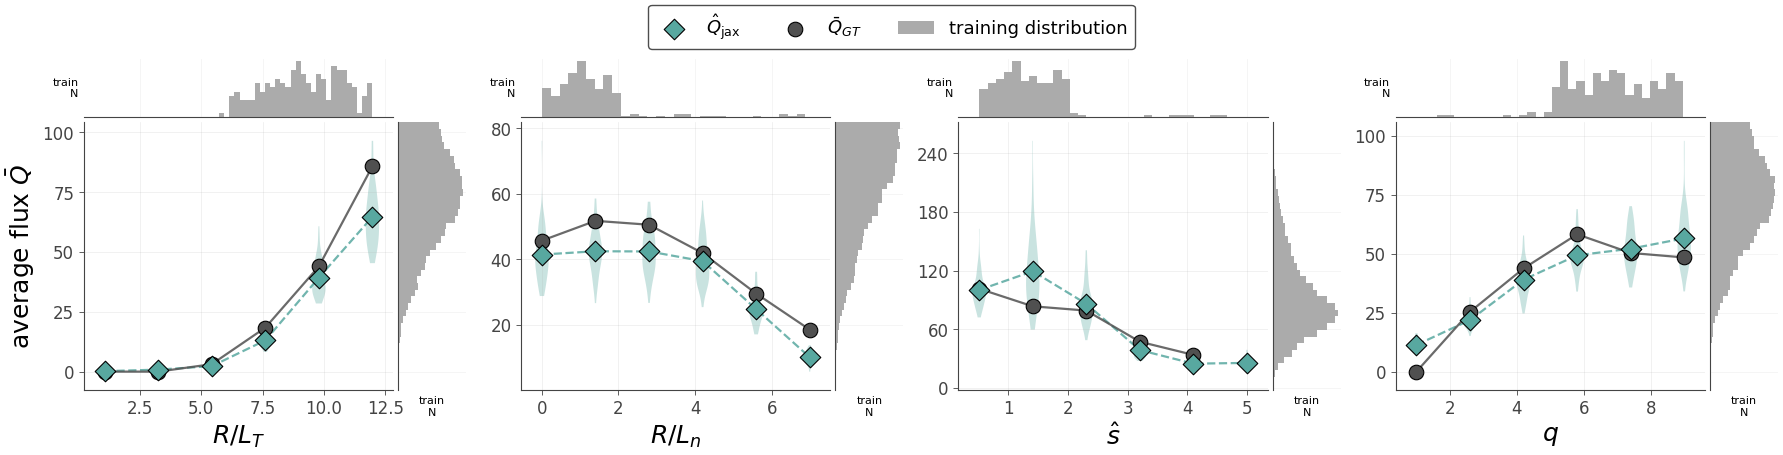

In [7]:
from neugk.utils import parse_input_dat

def _expand_ranges(spec):
    out = []
    for lo, hi in spec: out.extend(range(lo, hi + 1))
    return out

TRAIN_RANGES = [(0, 7), (9, 12), (14, 64), (67, 99), (101, 114), (116, 130),
                (132, 147), (149, 199), (201, 234), (236, 261), (263, 299)]
TRAIN_IDS = _expand_ranges(TRAIN_RANGES)

RAW_ROOT   = "/restricteddata/ukaea/gyrokinetics/raw"
SAT_OFFSET = 80
PARAM_KEY  = {"rlt": ("species","rlt"), "rln":("species","rln"),
              "shat":("geom","shat"), "q":("geom","q")}

train = {p: {"x": [], "flux": []} for p in PARAM_KEY}
flux_pool = []
for n in TRAIN_IDS:
    d = os.path.join(RAW_ROOT, f"iteration_{n}")
    inp = os.path.join(d, "input.dat")
    flx = os.path.join(d, "fluxes.dat")
    if not (os.path.isfile(inp) and os.path.isfile(flx)): continue
    try:
        cfg = parse_input_dat(inp)
        fl  = np.loadtxt(flx)
    except Exception:
        continue
    col = fl[:, 1] if fl.ndim == 2 and fl.shape[1] >= 2 else (fl if fl.ndim == 1 else None)
    if col is None or col.shape[0] <= SAT_OFFSET: continue
    first_flux = float(np.nanmean(col[:SAT_OFFSET]))
    last_flux  = float(np.nanmean(col[-SAT_OFFSET:]))
    if not (first_flux >= 1.0 and last_flux >= 1.0): continue
    tail = col[SAT_OFFSET:]; tail = tail[np.isfinite(tail)]
    if not tail.size: continue
    flux_pool.append(tail)
    for p, (sec, key) in PARAM_KEY.items():
        try:    v = float(cfg[sec][key])
        except Exception: continue
        train[p]["x"].append(v); train[p]["flux"].append(float(np.mean(tail)))
flux_pool = np.concatenate(flux_pool) if flux_pool else np.array([])
print(f"parsed {len(flux_pool)} flux samples across {sum(len(train[p]['x']) for p in PARAM_KEY)//4} trajectories")

COLOR_HIST = "#888888"
fig, axes = plt.subplots(1, 4, figsize=(18.0, 4.5), squeeze=False)
plt.subplots_adjust(wspace=0.55)
for col_i, param in enumerate(PARAMS):
    ax = axes[0, col_i]
    rows = sorted(scan_data.get(param, []), key=lambda r: r["x"])
    if not rows:
        ax.set_xlabel(PANEL_LABEL[param], fontsize=18); continue
    xs = np.array([r["x"] for r in rows])
    span = (xs.max() - xs.min()) if xs.size > 1 else 1.0
    width = 0.05 * max(span, 1e-6)
    pred_means = np.array([float(np.nanmean(r["samples"])) if np.isfinite(r["samples"]).any() else np.nan for r in rows])
    gts = np.array([r["gt"] for r in rows], dtype=float)
    m_p, m_g = np.isfinite(pred_means), np.isfinite(gts)
    if m_p.any(): ax.plot(xs[m_p], pred_means[m_p], color=COLOR_SCAN, lw=1.6, ls="--", alpha=0.85, zorder=3)
    if m_g.any(): ax.plot(xs[m_g], gts[m_g], color=COLOR_GT, lw=1.6, ls="-", alpha=0.85, zorder=3)
    for r in rows:
        f = r["samples"][np.isfinite(r["samples"])]
        if f.size >= 3 and f.std() > 0:
            parts = ax.violinplot(f, positions=[r["x"]], widths=width,
                                  showmeans=False, showmedians=False, showextrema=False)
            for pc in parts["bodies"]:
                pc.set_facecolor(COLOR_SCAN); pc.set_edgecolor("none"); pc.set_alpha(0.32)
        if f.size:
            ax.scatter([r["x"]], [float(f.mean())], s=110, facecolor=COLOR_SCAN, edgecolor="black", lw=0.8, marker="D", zorder=5)
        if np.isfinite(r["gt"]):
            ax.scatter([r["x"]], [r["gt"]], s=110, facecolor=COLOR_GT, edgecolor="black", lw=0.8, marker="o", zorder=4)
    ax.set_xlabel(PANEL_LABEL[param], fontsize=18)
    if col_i == 0: ax.set_ylabel(r"average flux $\bar{Q}$", fontsize=18)
    ax.tick_params(axis="both", labelsize=12)
    ax.yaxis.set_major_locator(MaxNLocator(5))
    lo, hi = [], []
    for r in rows:
        s = np.asarray(r["samples"], dtype=float); s = s[np.isfinite(s)]
        if s.size: lo.append(float(s.min())); hi.append(float(s.max()))
    pool = np.concatenate([pred_means[m_p], gts[m_g], np.asarray(lo, dtype=float), np.asarray(hi, dtype=float)])
    if pool.size:
        pad = 0.08 * max(pool.max() - pool.min(), 1e-3)
        ax.set_ylim(pool.min() - pad, pool.max() + pad)
    ymin_p, ymax_p = ax.get_ylim()
    ax.grid(alpha=0.25)
    div = make_axes_locatable(ax)
    ax_top   = div.append_axes("top",   size="22%", pad=0.05, sharex=ax)
    ax_right = div.append_axes("right", size="22%", pad=0.05, sharey=ax)
    train_p = np.asarray(train[param]["x"], dtype=float)
    if train_p.size: ax_top.hist(train_p, bins=30, color=COLOR_HIST, edgecolor="none", alpha=0.7)
    ax_top.set_yticks([]); ax_top.tick_params(axis="x", labelbottom=False, length=0)
    for s in ("top", "right", "left"): ax_top.spines[s].set_visible(False)
    ax_top.set_ylabel("train\nN", fontsize=8, rotation=0, ha="right", va="center")
    if flux_pool.size:
        clipped = flux_pool[(flux_pool >= ymin_p) & (flux_pool <= ymax_p)]
        if clipped.size:
            ax_right.hist(clipped, bins=40, orientation="horizontal",
                          range=(ymin_p, ymax_p), color=COLOR_HIST, edgecolor="none", alpha=0.7)
    ax_right.set_xticks([]); ax_right.tick_params(axis="y", labelleft=False, length=0)
    for s in ("top", "right", "bottom"): ax_right.spines[s].set_visible(False)
    ax_right.set_xlabel("train\nN", fontsize=8)

h_p = axes[0, 0].scatter([], [], s=110, facecolor=COLOR_SCAN, edgecolor="black", lw=0.8, marker="D")
h_g = axes[0, 0].scatter([], [], s=110, facecolor=COLOR_GT,   edgecolor="black", lw=0.8, marker="o")
h_t = plt.Rectangle((0, 0), 1, 1, facecolor=COLOR_HIST, alpha=0.7, edgecolor="none")
fig.legend([h_p, h_g, h_t],
           [r"$\hat{Q}_{\mathrm{jax}}$", r"$\bar{Q}_{GT}$", "training distribution"],
           loc="upper center", bbox_to_anchor=(0.5, 1.04), ncol=3,
           fontsize=13, frameon=True, edgecolor=COLOR_REF)
fig.tight_layout(rect=(0, 0, 1, 0.93))
try:    save_fig(fig, "param_scans_with_marginals", RESULTS_DIR)
except Exception: pass
plt.show()
